# Banana Ripeness Classification – Midterm (M2)
**Nhóm BaNaNaNoNoN – 22PFIEV2** | Baseline CNN + MobileNetV3 Transfer Learning + Demo

Quy trình: nạp dữ liệu → chia **trên ảnh gốc** (tránh rò rỉ) → augmentation chỉ trên train → CNN baseline → MobileNetV3 → so sánh → demo.

**Trước khi chạy:** tải dataset BananaImageBD từ Mendeley (https://data.mendeley.com/datasets/ptfscwtnyz/2), giải nén và đặt lên Google Drive (hoặc upload zip lên Colab), rồi sửa `DATA_DIR` ở cell 2. Runtime → Change runtime type → GPU.

In [4]:
import os, random, glob
import numpy as np, pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.22.0-rc0 []


In [6]:
# ====== CẤU HÌNH ======
DATA_DIR = r'D:\AI\BananaImageBD A Comprehensive Image Dataset of Common Banana Varieties with Different Ripeness Stages in Bangladesh'

IMG_SIZE = (224, 224)
BATCH = 32
CLASSES = ['unripe', 'ripe', 'overripe']
EXCLUDE_KEYWORD = 'augment'   # bỏ thư mục bản augmented để tránh data leakage

## 1. Nạp danh sách ảnh gốc và gộp 4 nhóm → 3 lớp

In [10]:
import os

print('DATA_DIR tồn tại:', os.path.isdir(DATA_DIR))
print('Thư mục con:', os.listdir(DATA_DIR))

def map_label(path):
    rel = os.path.relpath(path, DATA_DIR).lower().replace('\\', '/')
    name = ' '.join(rel.split('/')[:-1])       # chỉ xét thư mục bên trong dataset, bỏ tên file
    if 'over' in name: return 'overripe'
    if any(k in name for k in ['unripe', 'green', 'semi']): return 'unripe'
    if 'ripe' in name: return 'ripe'
    return None

rows = []
for root, dirs, fnames in os.walk(DATA_DIR):
    for fn in fnames:
        if not fn.lower().endswith(('.jpg', '.jpeg', '.png')): continue
        f = os.path.join(root, fn)
        rel = os.path.relpath(f, DATA_DIR).lower()
        if EXCLUDE_KEYWORD in rel: continue
        lab = map_label(f)
        if lab: rows.append((f, lab))

df = pd.DataFrame(rows, columns=['path', 'label']).drop_duplicates('path')
df['y'] = df['label'].map({c: i for i, c in enumerate(CLASSES)})
print(len(df), 'ảnh gốc')
print(df['label'].value_counts())
assert len(df) > 0, 'Không tìm thấy ảnh - kiểm tra lại DATA_DIR / tên thư mục lớp'

DATA_DIR tồn tại: True
Thư mục con: ['Augmented Banana Classification Dataset.zip', 'Augmented Banana Ripeness Detection Dataset.zip', 'Banana Classification Dataset', 'Banana Classification Dataset.zip', 'Banana Ripeness Detection Dataset', 'Banana Ripeness Detection Dataset.zip']
820 ảnh gốc
label
unripe      416
overripe    203
ripe        201
Name: count, dtype: int64


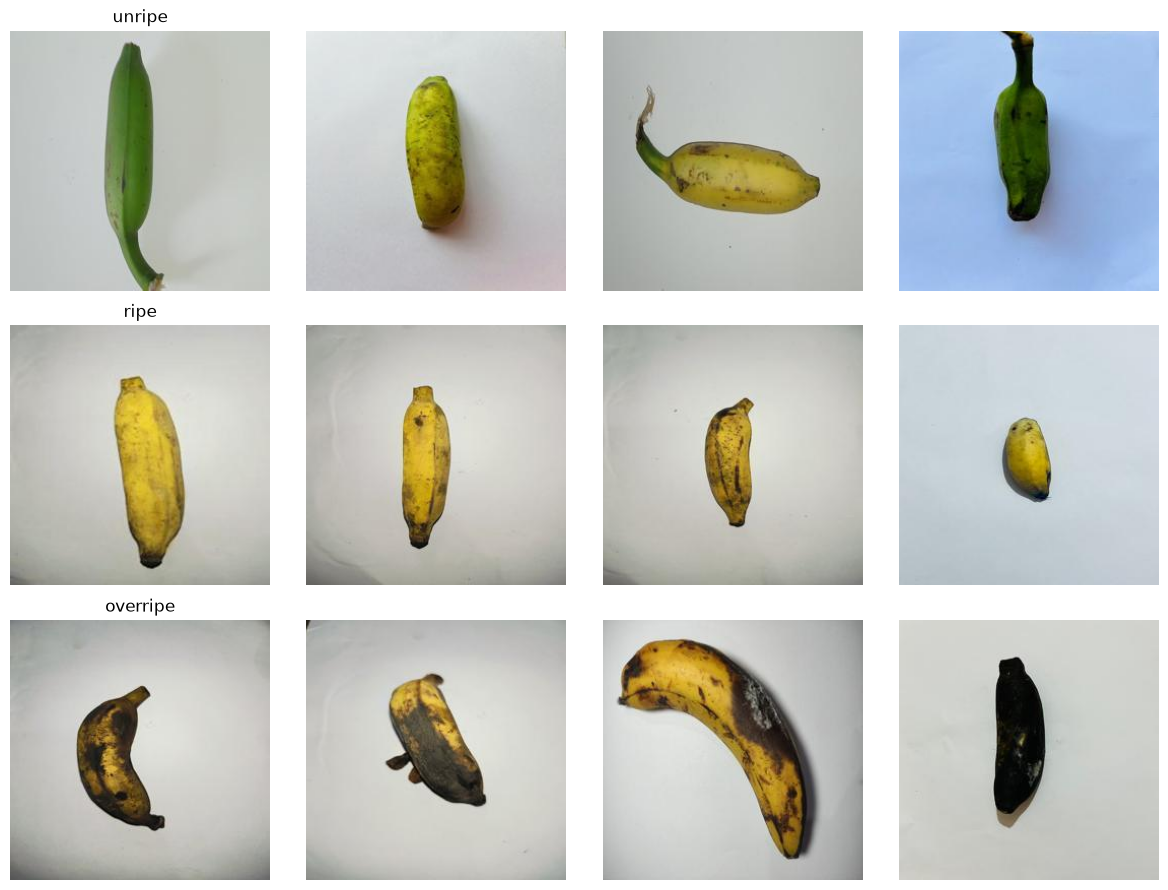

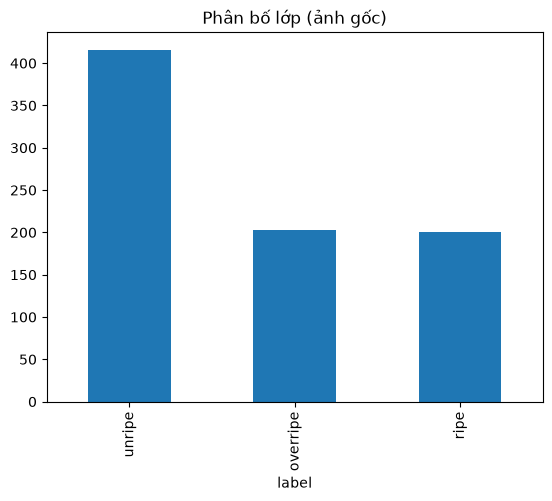

In [11]:
# Kiểm tra nhanh vài ảnh mỗi lớp
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i, c in enumerate(CLASSES):
    sample = df[df.label == c].sample(4, random_state=SEED)
    for j, p in enumerate(sample.path):
        axes[i, j].imshow(keras.utils.load_img(p)); axes[i, j].axis('off')
        if j == 0: axes[i, j].set_title(c)
plt.tight_layout(); plt.show()
df['label'].value_counts().plot(kind='bar', title='Phân bố lớp (ảnh gốc)'); plt.show()

## 2. Chia Train/Val/Test = 70/15/15 (stratified, trên ảnh gốc)

In [12]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['y'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['y'], random_state=SEED)
for n, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(n, len(d), d['label'].value_counts().to_dict())

# Class weights để bù mất cân bằng (Unripe nhiều gấp đôi)
counts = train_df['y'].value_counts().sort_index().values
class_weight = {i: len(train_df) / (len(CLASSES) * c) for i, c in enumerate(counts)}
print('class_weight:', class_weight)

train 574 {'unripe': 291, 'overripe': 142, 'ripe': 141}
val 123 {'unripe': 63, 'ripe': 30, 'overripe': 30}
test 123 {'unripe': 62, 'overripe': 31, 'ripe': 30}
class_weight: {0: np.float64(0.6575028636884307), 1: np.float64(1.3569739952718676), 2: np.float64(1.3474178403755868)}


## 3. Pipeline dữ liệu + Data Augmentation (chỉ train)

In [13]:
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1, value_range=(0, 255)),
    layers.RandomContrast(0.1),
], name='augmentation')

def load(path, y):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32), y      # giữ thang 0-255

def make_ds(d, train=False):
    ds = tf.data.Dataset.from_tensor_slices((d['path'].values, d['y'].values))
    if train: ds = ds.shuffle(len(d), seed=SEED)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if train: ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds, val_ds, test_ds = make_ds(train_df, True), make_ds(val_df), make_ds(test_df)

## 4. Mô hình 1 – CNN Baseline

In [14]:
def build_baseline():
    inp = keras.Input((*IMG_SIZE, 3))
    x = layers.Rescaling(1/255.)(inp)
    x = layers.Conv2D(32, 3, activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(len(CLASSES), activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_baseline')

# Lưu ý: dùng sparse_categorical_crossentropy (tương đương categorical CE với nhãn one-hot)
baseline = build_baseline()
baseline.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
h_base = baseline.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[es], class_weight=class_weight)

Epoch 1/30


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step - accuracy: 0.4930 - loss: 4.0214 - val_accuracy: 0.5528 - val_loss: 0.8508
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 461ms/step - accuracy: 0.7404 - loss: 0.6594 - val_accuracy: 0.7724 - val_loss: 0.5525
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 463ms/step - accuracy: 0.7666 - loss: 0.5189 - val_accuracy: 0.8374 - val_loss: 0.3745
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 459ms/step - accuracy: 0.8397 - loss: 0.4189 - val_accuracy: 0.7236 - val_loss: 0.7103
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 454ms/step - accuracy: 0.8031 - loss: 0.4834 - val_accuracy: 0.7642 - val_loss: 0.6012
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 460ms/step - accuracy: 0.8293 - loss: 0.4352 - val_accuracy: 0.8455 - val_loss: 0.3718
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 480ms/step - accuracy: 0.8955 - loss: 0.2928 - val_accuracy: 0.9187 - val_loss: 0.2331
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 468ms/step - accuracy: 0.9042 - loss: 0.2694 - val_accuracy: 0.9106 - val

## 5. Mô hình 2 – MobileNetV3 Transfer Learning

In [15]:
def build_mnv3(trainable_base=False):
    base = keras.applications.MobileNetV3Large(input_shape=(*IMG_SIZE, 3), include_top=False,
                                               weights='imagenet', include_preprocessing=True)
    base.trainable = trainable_base            # MobileNetV3 tự xử lý thang 0-255
    inp = keras.Input((*IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(len(CLASSES), activation='softmax')(x)
    return keras.Model(inp, out, name='mobilenetv3'), base

mnv3, base = build_mnv3()
mnv3.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
h_mnv3 = mnv3.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[es], class_weight=class_weight)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 26s 2us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 541ms/step - accuracy: 0.5192 - loss: 0.8804 - val_accuracy: 0.7480 - val_loss: 0.6533
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 365ms/step - accuracy: 0.8589 - loss: 0.4154 - val_accuracy: 0.8130 - val_loss: 0.4443
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 385ms/step - accuracy: 0.8955 - loss: 0.2946 - val_accuracy: 0.8374 - val_loss: 0.4066
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 356ms/step - accuracy: 0.9146 - loss: 0.2609 - val_accuracy: 0.8537 - val_loss: 0.3540
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 371ms/step - accuracy: 0.9321 - loss: 0.2266 - val_accuracy: 0.8699 - val_loss: 0.3474
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 368ms/step - accuracy: 0.9321 - loss: 0.2019 - val_accuracy: 0.8780 - val_loss: 0.3196
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 352ms/step - accuracy: 0.9408 - loss: 0.1825 - val_accuracy: 0.8780 - val_loss: 0.3049
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 372ms/step

In [17]:
# (Tuỳ chọn) Fine-tune ~30 layer cuối với learning rate nhỏ
base.trainable = True
for l in base.layers[:-30]: l.trainable = False
for l in base.layers:
    if isinstance(l, layers.BatchNormalization): l.trainable = False
mnv3.compile(optimizer=keras.optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
h_ft = mnv3.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[es], class_weight=class_weight)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 668ms/step - accuracy: 0.9582 - loss: 0.0968 - val_accuracy: 0.9431 - val_loss: 0.1818
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 447ms/step - accuracy: 0.9774 - loss: 0.0559 - val_accuracy: 0.9431 - val_loss: 0.1531
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 442ms/step - accuracy: 0.9861 - loss: 0.0393 - val_accuracy: 0.9268 - val_loss: 0.1749
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.9861 - loss: 0.0347 - val_accuracy: 0.9431 - val_loss: 0.1686
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 427ms/step - accuracy: 0.9930 - loss: 0.0230 - val_accuracy: 0.9431 - val_loss: 0.2055
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 426ms/step - accuracy: 0.9930 - loss: 0.0202 - val_accuracy: 0.9350 - val_loss: 0.1928


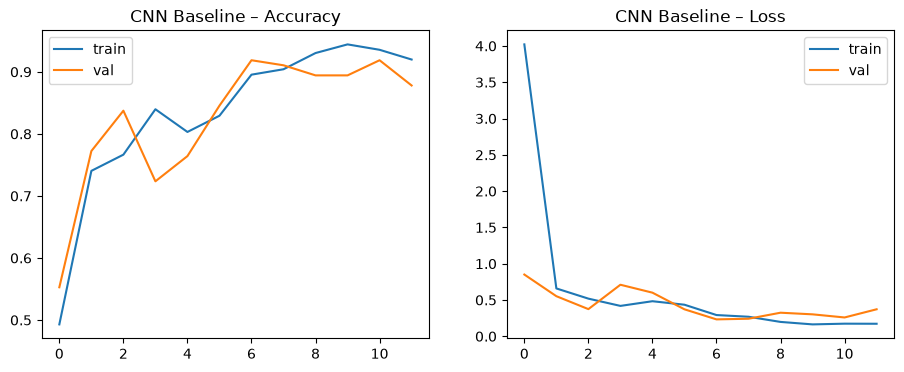

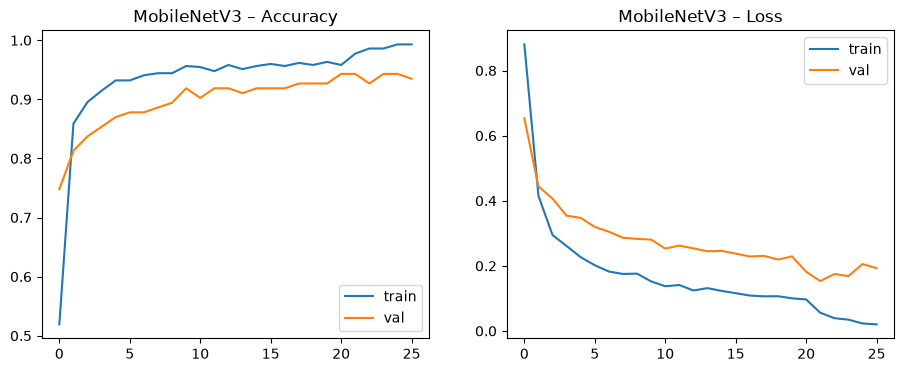

In [18]:
def plot_hist(hists, title):
    acc = sum([h.history['accuracy'] for h in hists], []); vacc = sum([h.history['val_accuracy'] for h in hists], [])
    loss = sum([h.history['loss'] for h in hists], []); vloss = sum([h.history['val_loss'] for h in hists], [])
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(acc, label='train'); ax[0].plot(vacc, label='val'); ax[0].set_title(title + ' – Accuracy'); ax[0].legend()
    ax[1].plot(loss, label='train'); ax[1].plot(vloss, label='val'); ax[1].set_title(title + ' – Loss'); ax[1].legend()
    plt.show()
plot_hist([h_base], 'CNN Baseline'); plot_hist([h_mnv3, h_ft], 'MobileNetV3')

## 6. Đánh giá trên tập Test và so sánh

===== CNN Baseline =====
              precision    recall  f1-score   support

      unripe     0.8923    0.9355    0.9134        62
        ripe     0.8333    0.8333    0.8333        30
    overripe     1.0000    0.9032    0.9492        31

    accuracy                         0.9024       123
   macro avg     0.9085    0.8907    0.8986       123
weighted avg     0.9051    0.9024    0.9029       123



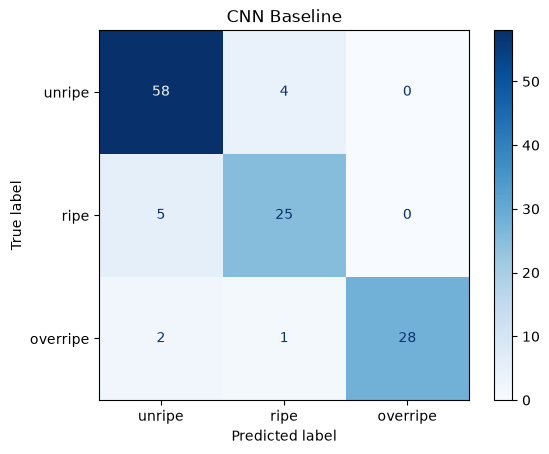

===== MobileNetV3 =====
              precision    recall  f1-score   support

      unripe     0.9508    0.9355    0.9431        62
        ripe     0.8788    0.9667    0.9206        30
    overripe     1.0000    0.9355    0.9667        31

    accuracy                         0.9431       123
   macro avg     0.9432    0.9459    0.9435       123
weighted avg     0.9456    0.9431    0.9436       123



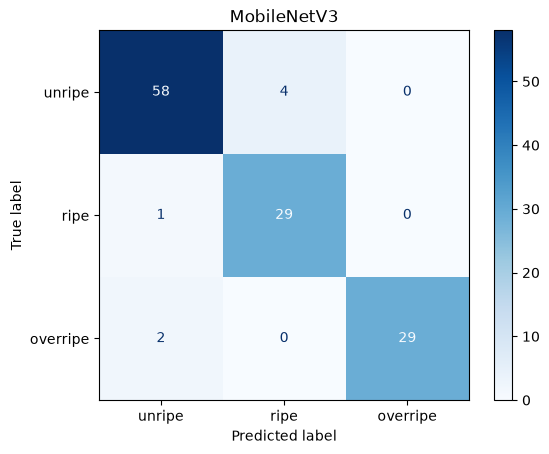

,Model,Accuracy,Macro-F1,Weighted-F1,Đạt ≥85%
0,CNN Baseline,0.902439,0.898624,0.902875,True
1,MobileNetV3,0.943089,0.943464,0.943555,True


In [19]:
y_true = test_df['y'].values   # test_ds không shuffle nên thứ tự khớp

def evaluate(model, name):
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    print(f'===== {name} =====')
    print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(cmap='Blues')
    plt.title(name); plt.show()
    return {'Model': name, 'Accuracy': accuracy_score(y_true, y_pred),
            'Macro-F1': f1_score(y_true, y_pred, average='macro'),
            'Weighted-F1': f1_score(y_true, y_pred, average='weighted')}

results = pd.DataFrame([evaluate(baseline, 'CNN Baseline'), evaluate(mnv3, 'MobileNetV3')])
results['Đạt ≥85%'] = (results['Accuracy'] >= 0.85) & (results['Macro-F1'] >= 0.85)
results

In [20]:
os.makedirs('models', exist_ok=True)
baseline.save('models/cnn_baseline.keras'); mnv3.save('models/mobilenetv3.keras')
results.to_csv('models/results.csv', index=False)

## 7. Demo: upload ảnh và nhận kết quả

In [21]:

import gradio as gr

best = mnv3 if results.loc[1, 'Macro-F1'] >= results.loc[0, 'Macro-F1'] else baseline

def predict(img):
    x = tf.image.resize(tf.convert_to_tensor(img, dtype=tf.float32), IMG_SIZE)[None]
    p = best.predict(x, verbose=0)[0]
    return {c: float(p[i]) for i, c in enumerate(CLASSES)}

gr.Interface(fn=predict, inputs=gr.Image(type='numpy', label='Ảnh chuối'),
             outputs=gr.Label(num_top_classes=3, label='Độ chín + confidence'),
             title='Banana Ripeness Classifier').launch()

c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
